# Prior Simulation based calibration

In [1]:
from arviz_plots import plot_ecdf_pit, style
import numpy as np
import simuk
style.use("arviz-variat")

## Out-of-the-box Prior SBC
This example demonstrates how to use the `SBC` class for prior simulation-based calibration, supporting PyMC, Bambi and Numpyro models. By default, the generative model implied by the probabilistic model is used.

We perform Prior SBC on the centered eight school model, which is known to have a funnel-shaped posterior distribution. The inference algorithm struggles with this model when $\tau$ is small, and thus we expect to see deviations from the uniform distribution in the rank statistics.


### PyMC

First, define a PyMC model. In this example, we will use the centered eight schools model.

In [2]:
import pymc as pm

data = np.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
sigma = np.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])

with pm.Model() as centered_eight:
    mu = pm.Normal('mu', mu=0, sigma=5)
    tau = pm.HalfCauchy('tau', beta=5)
    theta = pm.Normal('theta', mu=mu, sigma=tau, shape=8)
    y_obs = pm.Normal('y', mu=theta, sigma=sigma, observed=data)

Pass the model to the SBC class, set the number of simulations to 100, and run the simulations. This process may take
some time since the model runs multiple times (100 in this example).

In [ ]:
sbc = simuk.SBC(centered_eight,
    num_simulations=100,
    sample_kwargs={'draws': 100, 'tune': 100})

sbc.run_simulations();

To compare the prior and posterior distributions, we will plot the results from the simulations,
using the ArviZ function `plot_ecdf_pit`.
If the inference algorithm was well-calibrated, we expect a uniform distribution that lies within the 94% credible interval, indicated by not having any red points.
In our case, we see a clear deviation from the uniform distribution.

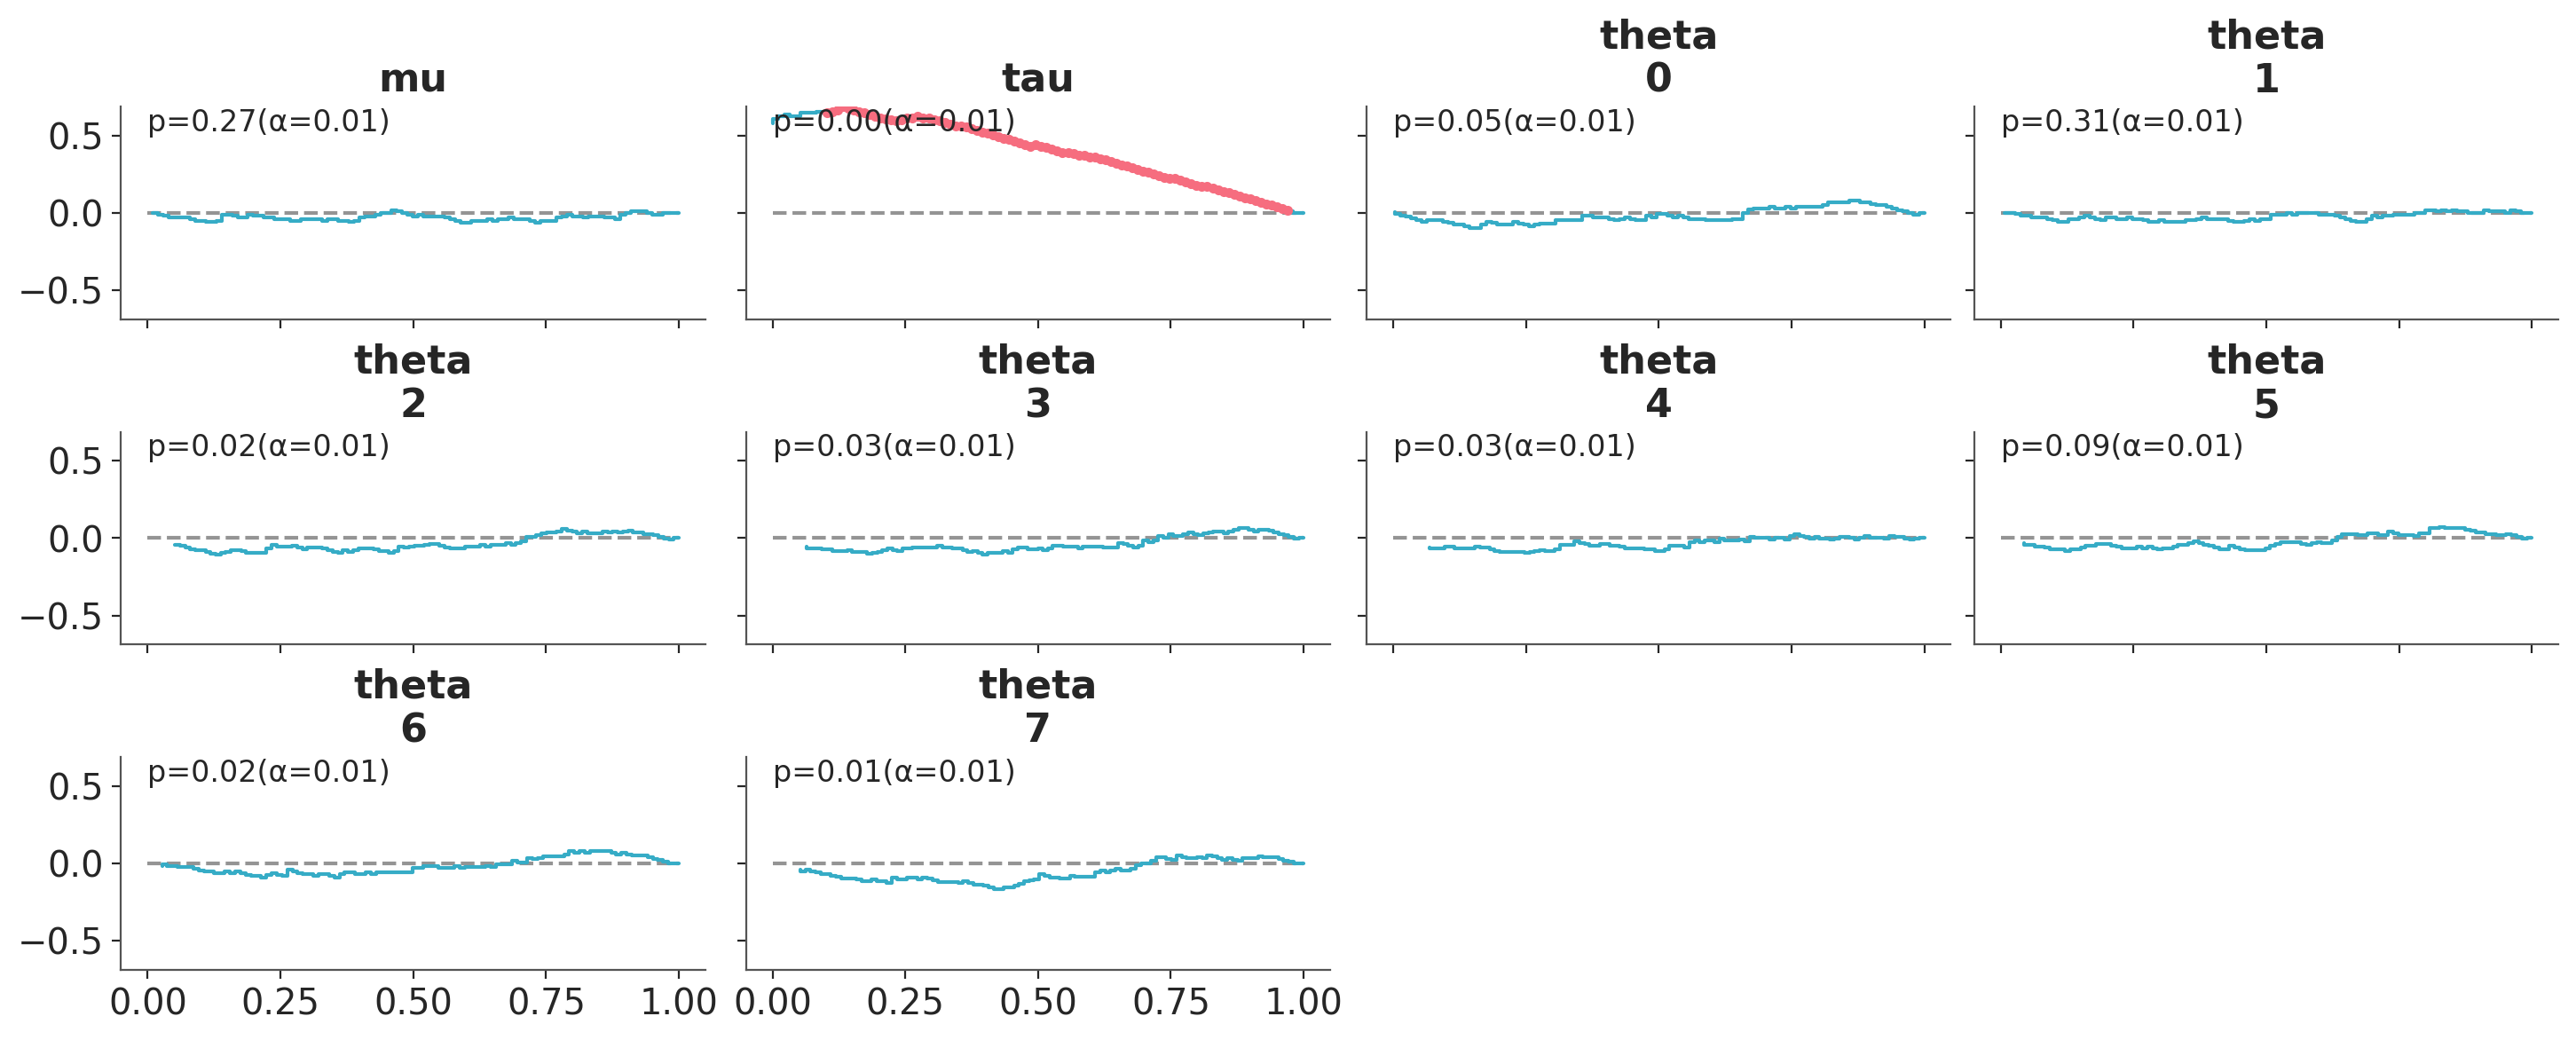

In [4]:
plot_ecdf_pit(sbc.simulations,
              visuals={"xlabel":False},
);

### Bambi

Now, we define a Bambi Model.

In [5]:
import bambi as bmb
import pandas as pd

x = np.random.normal(0, 1, 200)
y = 2 + np.random.normal(x, 1)
df = pd.DataFrame({"x": x, "y": y})
bmb_model = bmb.Model("y ~ x", df)

Pass the model to the `SBC` class, set the number of simulations to 100, and run the simulations.
This process may take some time, as the model runs multiple times

In [6]:
sbc = simuk.SBC(bmb_model,
    num_simulations=100,
    sample_kwargs={'draws': 25, 'tune': 50})

sbc.run_simulations();

To compare the prior and posterior distributions, we will plot the results from the simulations.
If the inference algorithm was well-calibrated, we expect a uniform distribution that lies within the 94% credible interval, indicated by not having any red points.

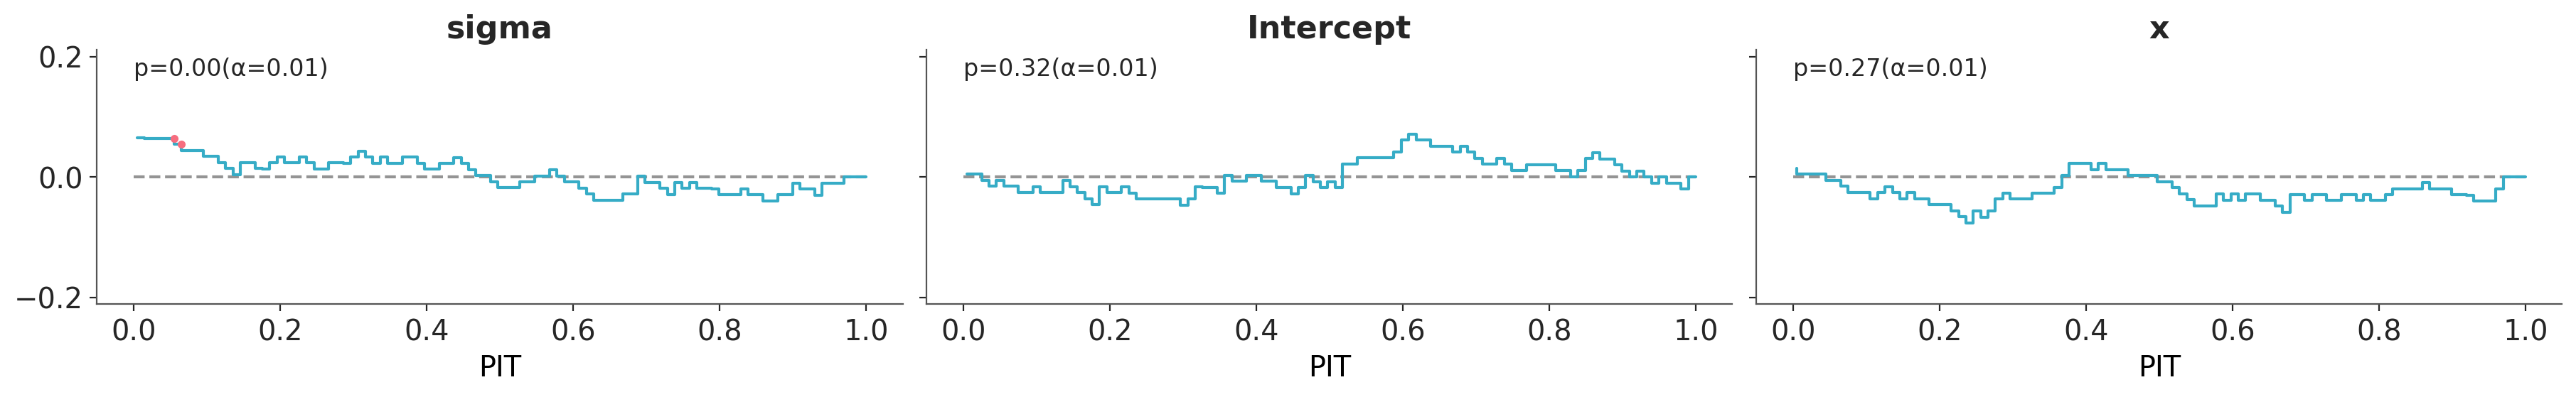

In [7]:
plot_ecdf_pit(sbc.simulations)

### Numpyro

We define a Numpyro Model, we use the centered eight schools model.

In [ ]:
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import NUTS

y = np.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
sigma = np.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])

def eight_schools_cauchy_prior(J, sigma, y=None):
    mu = numpyro.sample("mu", dist.Normal(0, 5))
    tau = numpyro.sample("tau", dist.HalfCauchy(5))
    with numpyro.plate("J", J):
        theta = numpyro.sample("theta", dist.Normal(mu, tau))
    numpyro.sample("y", dist.Normal(theta, sigma), obs=y)

# We use the NUTS sampler
nuts_kernel = NUTS(eight_schools_cauchy_prior)

Pass the model to the `SBC` class, set the number of simulations to 100, and run the simulations. For numpyro model,
we pass in the ``data_dir`` parameter.

In [9]:
sbc = simuk.SBC(nuts_kernel,
    sample_kwargs={"num_warmup": 50, "num_samples": 75},
    num_simulations=100,
    data_dir={"J": 8, "sigma": sigma, "y": y},
)
sbc.run_simulations()

100%|██████████| 100/100 [01:49<00:00,  1.09s/it]


To compare the prior and posterior distributions, we will plot the results from the simulations,
using the ArviZ function `plot_ecdf_pit`.
If the inference algorithm was well-calibrated, we expect a uniform distribution that lies within the 94% credible interval, indicated by not having any red points.
In our case, we see a clear deviation from the uniform distribution.

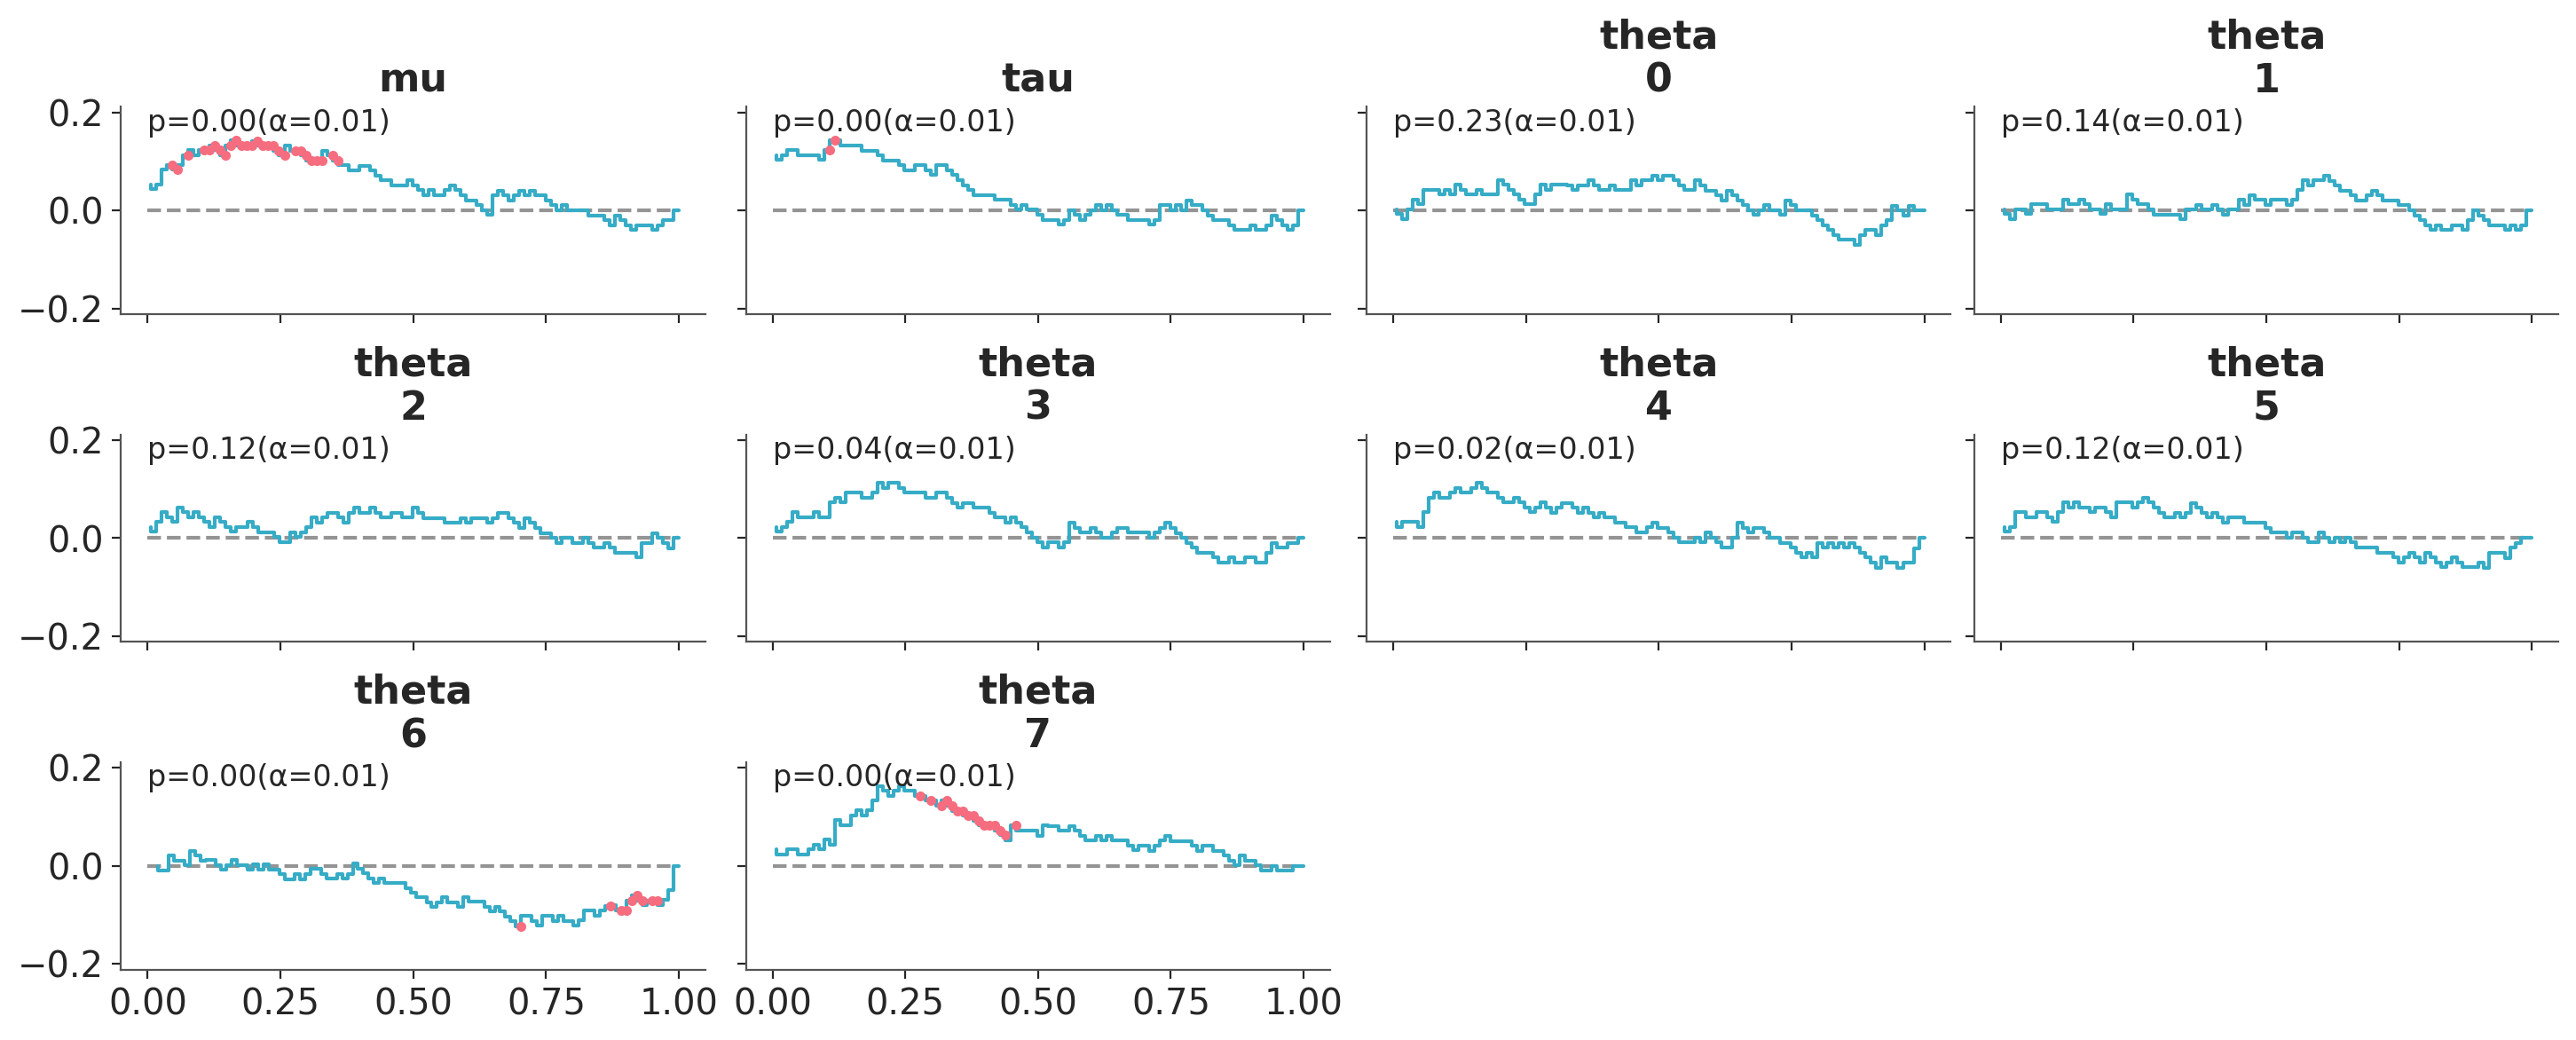

In [10]:
plot_ecdf_pit(sbc.simulations,
              visuals={"xlabel":False},
);

## Custom simulator SBC

### PyMC

In certain scenarios, you might want to pass a custom function to the `SBC` class to generate the data. For instance, if you aim to evaluate the effect of model misspecification by generating data from a different model than the one used for model fitting.

Next, we determine the impact of occasional large deviations (outliers) by drawing from a Laplace distribution instead of a normal distribution (which we use to fit the model).

In [ ]:
def simulator(theta, seed, **kwargs):
    rng = np.random.default_rng(seed)
    # Here we use a Laplace distribution, but it could also be some mechanistic simulator
    scale = sigma / np.sqrt(2)
    return {"y": rng.laplace(theta, scale)}

sbc = simuk.SBC(centered_eight,
    num_simulations=100,
    simulator=simulator,
    sample_kwargs={'draws': 25, 'tune': 50})

sbc.run_simulations();

### Bambi

In certain scenarios, you might want to pass a custom function to the `SBC` class to generate the data. For instance, if you aim to evaluate the effect of model misspecification by generating data from a different model than the one used for model fitting.

Next, we determine the impact of occasional large deviations (outliers) by drawing from a Laplace distribution instead of a normal distribution (which we use to fit the model).

In [ ]:
def simulator(mu, seed, sigma, **kwargs):
    rng = np.random.default_rng(seed)
    # Here we use a Laplace distribution, but it could also be some mechanistic simulator
    scale = sigma / np.sqrt(2)
    return {"y": rng.laplace(mu, scale)}

sbc = simuk.SBC(bmb_model,
    num_simulations=100,
    simulator=simulator,
    sample_kwargs={'draws': 25, 'tune': 50})

sbc.run_simulations();

### Numpyro

In certain scenarios, you might want to pass a custom function to the `SBC` class to generate the data. For instance, if you aim to evaluate the effect of model misspecification by generating data from a different model than the one used for model fitting.

Next, we determine the impact of occasional large deviations (outliers) by drawing from a Laplace distribution instead of a normal distribution (which we use to fit the model).

In [ ]:
def simulator(theta, seed, **kwargs):
    rng = np.random.default_rng(seed)
    # Here we use a Laplace distribution, but it could also be some mechanistic simulator
    scale = sigma / np.sqrt(2)
    return {"y": rng.laplace(theta, scale)}

sbc = simuk.SBC(nuts_kernel,
    sample_kwargs={"num_warmup": 50, "num_samples": 75},
    num_simulations=100,
    simulator=simulator,
    data_dir={"J": 8, "sigma": sigma, "y": y}
)

sbc.run_simulations();